In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')



In [ ]:

# 1(a)

def get_Z(rho, mu, T):
    """
    Simulates the accumulated mutations (Z) for a cell over time T.
    
    Parameters:
    rho: The cell's division rate.
    mu: The average mutation rate per division.
    T: The total time interval.
    
    Returns:
    The total number of mutations Z.
    """
    
    # Determine the total number of divisions(D)
    # The number of divisions follows a Poisson distribution with mean = rho * T
    expected_divisions = rho * T
    D =np.random.poisson(expected_divisions)
    
    # Handle the mutations for each division event
    # If no divisions occurred, the total mutations must be zero
    if D <= 0:
        return 0

    else:
        
        
        # mutation counts for each of the D divisions
        # Each division 'i' has a random number of mutations Mi  (Poisson(mu))
        mutations_per_event = np.random.poisson(mu, size=D)
        
        # Sum all mutations to find the final result Z
        total_mutations_z = np.sum(mutations_per_event)
        
        return total_mutations_z

# test the function 
sample = get_Z(2, 20, 50)
print(f"result (Z): {sample}")



result (Z): 2210


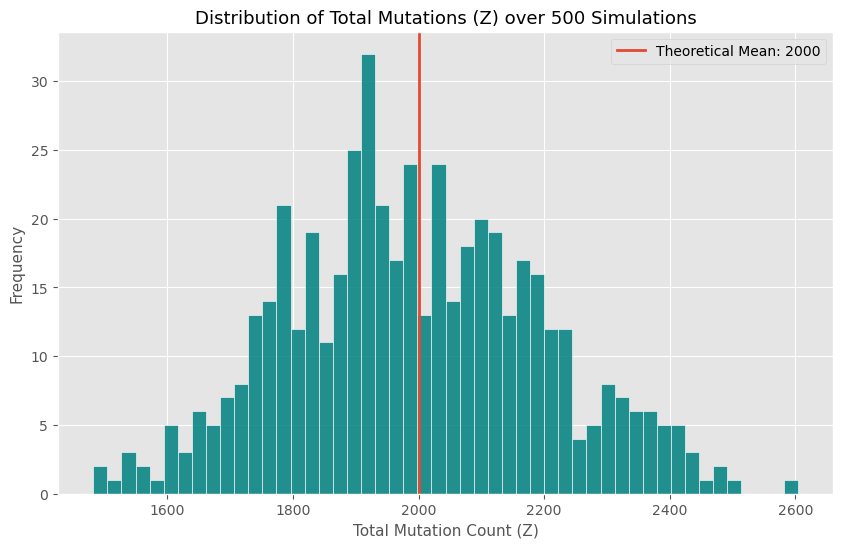

In [ ]:
#2(a)
# Parameters according to the question
RHO = 2      # divisions in one  day
MU = 20      # mutations per division
T_TOTAL = 50 # total days
TRIALS = 500 # number of simulations

# Collecting 500 samples of Z
z_results = [get_Z(RHO, MU, T_TOTAL) for _ in range(TRIALS)]

# Plot the histogram
plt.figure(figsize=(10, 6))

#  Using  50 bins for the plot
plt.hist(z_results, bins=50, color='teal', edgecolor='white', alpha=0.85)

# Adding labels and verification line
plt.title(f'Distribution of Total Mutations (Z) over {TRIALS} Simulations', fontsize=13)
plt.xlabel('Total Mutation Count (Z)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)

# Theoretical mean as a reference: E[Z] = rho * T * mu
theoretical_mean = RHO * T_TOTAL * MU
plt.axvline(theoretical_mean, linewidth=2, 
            label=f'Theoretical Mean: {theoretical_mean}')

plt.legend()
plt.show()

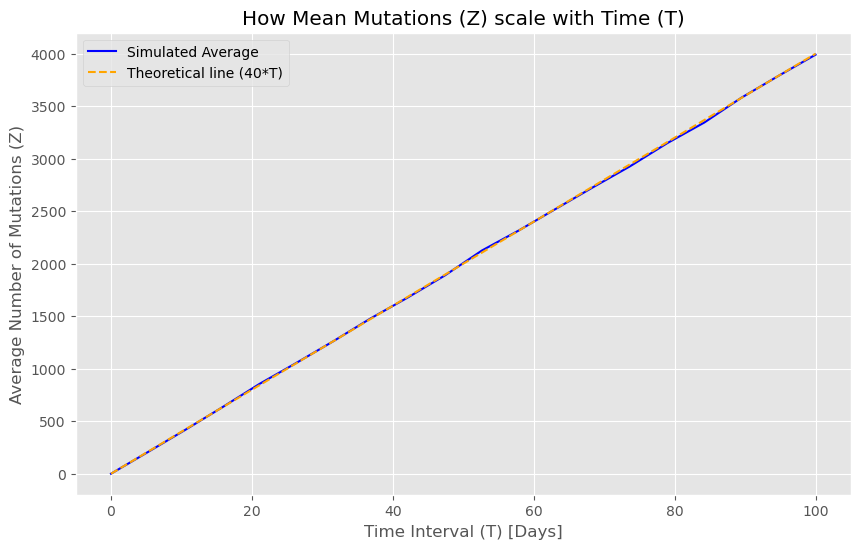

In [ ]:
# =====================================================================
# PROBLEM 1(c) - Average Z vs Time Interval (T)
# =====================================================================


def get_mean_z_value(rho, mu, T,TRIALS=500):
    """
    This runs the trial  500 times for a specific T and returns the average.
    """
    results = []
    for i in range (TRIALS):
        # Calling the  defined function get_Z
        z_sample = get_Z(rho, mu, T)
        results.append(z_sample)
    
    # return the average of 500 trials
    return np.mean(results)

# Generating array of data for creating the plot

# Use np.linspace to create 20 even space 
# it stars from 0 to 100 days
time_intervals = np.linspace(0, 100, 20)

# the mean Z for each time interval (using rho=2, mu=20)
average_mutations = [get_mean_z_value(RHO, MU, t) for t in time_intervals]



plt.figure(figsize=(10, 6))

# Plotting the simulated means (points connected by a line)
plt.plot(time_intervals, average_mutations, linestyle='-', color='blue', label='Simulated Average')

# reference line for the expected theoretical value (E[Z] = rho * mu * T)
# In this case: 2 * 20 * T 
plt.plot(time_intervals, 40 * time_intervals, color='orange', linestyle='--', label='Theoretical line (40*T)')

# Formatting the plot
plt.title('How Mean Mutations (Z) scale with Time (T)')
plt.xlabel('Time Interval (T) [Days]')
plt.ylabel('Average Number of Mutations (Z)')
plt.legend()
plt.show()

In [ ]:
#Problem2 :
#What classical model can be used to describe this system? 
# The classical model described here is the Moran Model.
# This is because the population size remains constant (N=100), and it follows a birth-death process where one cell is chosen to die
# and another is chosen to divide and replace it in each step.

In [ ]:
#2(a)

def get_differentiation_probability(mutant_size, total_size):
    """
    Calculates the probability that a randomly chosen cell for 
    differentiation (removal) is a mutant.
    
    Parameters:
    mutant_size: Number of mutant cells in the population.
    total_size: Total number of cells.
    
    Returns:
    Probability of picking a mutant.
    """
    
    # all cells have an equal chance of being chosen:
    # Probability = (Number of Mutants) / (Total Population)
    
    if total_size <= 0:
        return 0.0
        
    prob_mutant_leaves = mutant_size / total_size
    
    return prob_mutant_leaves

# If there are 20 mutants in 100 cells, the probability should be 0.2
test_probability  = get_differentiation_probability(20, 100)
print(f"Probability of mutant differentiation: {test_probability}")

Probability of mutant differentiation: 0.2


In [ ]:
#2(b)
def get_division_mutant_probability(mutant_size, total_size, s):
    """
    Calculates the probability that a mutant cell is chosen for division.
    The mutant has a fitness advantage 's'.
    """
    
    # X: Number of mutants
    # Y: Number of wildtype cells (Total - Mutants)
    X = mutant_size
    Y = total_size - mutant_size
    
    # Total Weight of mutants = X * s
    # Total Weight of population = (X * s) + Y*1
    
    # Numerator = X * s
    # Denominator = (X * s) + Y
    
    # Probability that any mutant is chosen
    prob_mutant_divides = (X * s) / ((X * s) + Y)
    
    return prob_mutant_divides

#  Test:
# If N=100, mutants=10, and s=2 (mutants are twice as fast)
# Prob = (10*2) / (10*2 + 90) = 20 / 110 ≈ 0.18
print(f"Probability of mutant division: {get_division_mutant_probability(10, 100, 2)}")

Probability of mutant division: 0.18181818181818182


In [ ]:
#2(c)
def run_moran_simulation(start_x, N, r_rate, s_value, max_time):
    """
    Follows how the number of mutants changes step-by-step until time T
    The simulation stops at max_time or if the mutant reaches fixation/extinction.
    """
    current_t = 0.0
    current_x = start_x
    
    # Store history for visualization
    history_t = [0.0]
    history_x = [start_x]
    
    # The rate of differentiation events in the niche
    total_rate = N * r_rate
    
    while current_t < max_time:
        # 1. Determine the time of the next event (Exponential Distribution)
        wait_time = np.random.exponential(1.0 / total_rate)
        current_t += wait_time
        
        # Limit the simulation to max_time
        if current_t > max_time:
            history_t.append(max_time)
            history_x.append(current_x)
            break
            
        # 2. Check for absorption (No more changes possible if X=0 or X=N)
        if current_x == 0 or current_x == N:
            history_t.append(max_time)
            history_x.append(current_x)
            break
            
        # 3. Get event probabilities
        p_death = get_differentiation_probability(current_x, N)
        p_birth = get_division_mutant_probability(current_x, N, s_value)
        
        # 4. Stochastic outcomes: determine which types are chosen
        die_is_mutant = np.random.random() < p_death
        birth_is_mutant = np.random.random() < p_birth
        
        # 5. Update the population based on birth-death results
        if die_is_mutant and not birth_is_mutant:
            current_x -= 1 # Mutant died, Wildtype replaced it
        elif not die_is_mutant and birth_is_mutant:
            current_x += 1 # Wildtype died, Mutant replaced it
            
        history_t.append(current_t)
        history_x.append(current_x)

        
    return np.array(history_t), np.array(history_x)

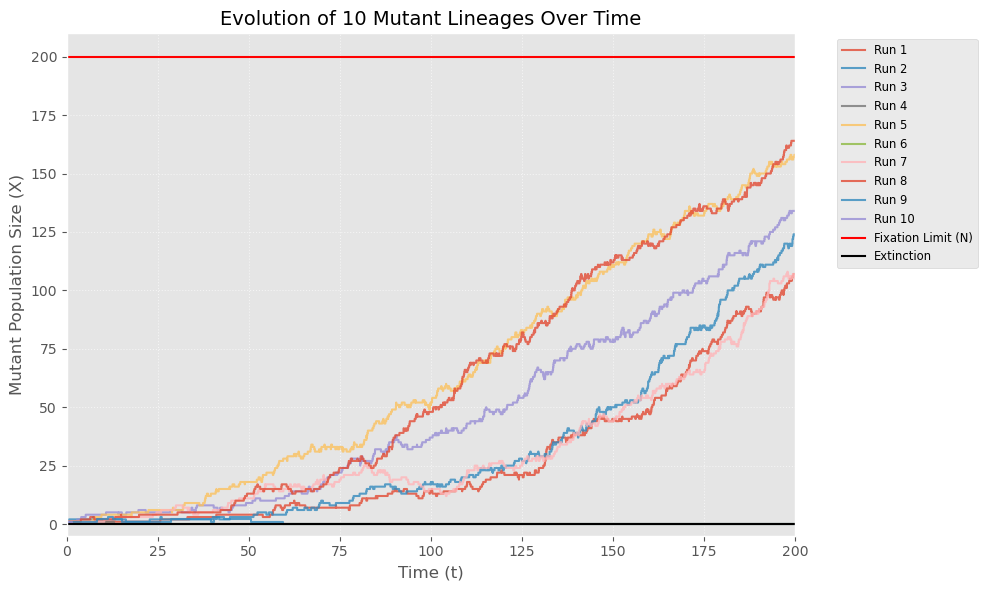

In [ ]:
#2(d)


# parameters based on the instructions
X0_initial = 1
N_population = 200
r0_rate = 0.03
s_fitness = 2.3
T_total = 200
num_runs = 10  # We want to see 10 different versions of the future

plt.figure(figsize=(10, 6))
# 2.run the simulation 10 times
for i in range(num_runs):
    # Execute the simulation for each run
    time_points, mutant_counts = run_moran_simulation(X0_initial, N_population, r0_rate, s_fitness, T_total)
    
    # Plot each trajectory. 
    # 'where=post' is used because the population stays constant between events
    plt.step(time_points, mutant_counts, where='post', alpha=0.8, label=f'Run {i+1}')

# 3. Formatting the plot for a professional look
plt.axhline(N_population, color='red', label='Fixation Limit (N)')
plt.axhline(0, color='black',label='Extinction')

plt.title(f'Evolution of {num_runs} Mutant Lineages Over Time', fontsize=14)
plt.xlabel('Time (t)', fontsize=12)
plt.ylabel('Mutant Population Size (X)', fontsize=12)
plt.xlim(0, T_total)  # Ensuring the x-axis shows exactly up to T
plt.ylim(-5, N_population + 10) # Adding a bit of space for clarity

# Place the legend outside if it gets too crowded
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
#2(e)
import numpy as np

def simulate_until_absorption(X, N, s, r0):
    """
    Simulates the Moran process until the population reaches a steady state:
    either complete extinction (X=0) or total fixation (X=N).
    """
    # The loop continues as long as the mutant hasn't died out or taken over
    while 0 < X < N:
        # 1. Calculate probabilities based on current population state
        # Death probability: neutral (proportional to frequency)
        p_death = X / N
        
        # Birth probability: weighted by selective fitness advantage 's'
        p_birth = (X * s) / (X * s + (N - X))
        
        # 2. Determine independent stochastic outcomes for birth and death
        mutant_dies = np.random.random() < p_death
        mutant_divides = np.random.random() < p_birth
        
        # 3. Update the mutant population count
        # X decreases if a mutant is removed and a wildtype replaces it
        if mutant_dies and not mutant_divides:
            X -= 1
        # X increases if a wildtype is removed and a mutant replaces it
        elif not mutant_dies and mutant_divides:
            X += 1
        # If both or neither are mutants, X remains unchanged for this step
            
    return X

def estimate_extinction_probability(X0, N, s, r0, n_simulations):
    """
    Repeats the simulation multiple times to find the empirical 
    probability that the mutant lineage fails to survive.
    """
    extinction_events = 0
    
    for _ in range(n_simulations):
        # Run a single realization until it hits 0 or N
        final_state = simulate_until_absorption(X0, N, s, r0)
        
        # Increment counter if the result was extinction
        if final_state == 0:
            extinction_events += 1
    
    # Return the ratio of extinctions to total trials
    return extinction_events / n_simulations

# --- Execution using provided parameters ---
X0_init = 1
N_pop = 200
s_fitness = 2.3
r0_rate = 0.03

# Run 1000 simulations to get a statistically significant estimate
p_extinction = estimate_extinction_probability(X0_init, N_pop, s_fitness, r0_rate, 1000)

print(f"Empirical Extinction Probability: {p_extinction}")

Empirical Extinction Probability: 0.431


In [ ]:

#2(f) 


def estimate_average_fixation_time(X0, N, r0, s, n_simulations=1000):
    """
    Estimates the mean time it takes for a mutant to reach fixation (X=N).
    We ignore simulations that end in extinction (X=0).
    """
    fixation_times = []
    
    for _ in range(n_simulations):
        # We need to track both time and population size
        current_t = 0.0
        X = X0
        total_rate = N * r0
        
        while 0 < X < N:
            # 1. Advance the clock using exponential wait time
            wait_time = np.random.exponential(1.0 / total_rate)
            current_t += wait_time
            
            # 2. Birth-Death probabilities
            p_death = X / N
            p_birth = (X * s) / (X * s + (N - X))
            
            # 3. Outcomes
            mutant_dies = np.random.random() < p_death
            mutant_divides = np.random.random() < p_birth
            
            # 4. Update state
            if mutant_dies and not mutant_divides:
                X -= 1
            elif not mutant_dies and mutant_divides:
                X += 1
        
        # We only record the time IF the mutant successfully fixed (X == N)
        if X == N:
            fixation_times.append(current_t)
            
    # Calculate the average of all successful fixation times
    if len(fixation_times) > 0:
        avg_time = np.mean(fixation_times)
    else:
        avg_time = 0
        
    return avg_time, len(fixation_times)

# --- Parameters and Execution ---
X0_f = 1
N_f = 200
r0_f = 0.03
s_f = 2.3

# Running the simulation
mean_time, successful_runs = estimate_average_fixation_time(X0_f, N_f, r0_f, s_f, 1000)

print(f"Average time until fixation: {mean_time:.2f} time units")
print(f"Based on {successful_runs} successful fixation events out of 1000 trials.")

Average time until fixation: 448.94 time units
Based on 538 successful fixation events out of 1000 trials.
